In [22]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from scipy.stats import pearsonr
from matplotlib.colors import LogNorm, Normalize

# =========================
# Configuration
# =========================

metrics = [
    "avg norm rank of source_mean",
    "accuracy_mean",
    "source in top 20_mean",
]

metadata_metrics = [
    "average_degree", 
    "density", 
    "number_of_nodes", 
    "number_of_perturbed_genes_in_pathway", 
    "number_of_edges", 
    "number_of_sig_info_in_pathway"
]

kegg_file = "kegg_nodes_metrics.json"
metadata_metric_for_nodecolor = "number_of_nodes"

# Define ranges for filtering (optional)
# Format: {"metric_name": (min_value, max_value)}
# Set to None or empty dict to disable filtering
metadata_ranges = {
    #"number_of_perturbed_genes_in_pathway": (60, 70),  # Example: only show pathways with 60-70 nodes
    #"average_degree": (1.0, 3.0),  # Example: uncomment to filter by degree
    #"number_of_sig_info_in_pathway": (4500, 20000),
}

# =========================
# Helpers
# =========================

def normalize_name(name: str) -> str:
    base = name.lower()
    base = base.replace("_", " ")
    base = base.replace("-", " ")
    base = base.split("(")[0]
    base = base.replace("pathway", "")
    base = base.strip()
    return "_".join(base.split())


def aggregate_mean_std(stats):
    """
    stats: list of tuples (n, mean, std)
    returns: (mean, std)
    """
    total_n = sum(n for n, _, _ in stats)
    if total_n == 0:
        return np.nan, np.nan

    mean = sum(n * m for n, m, _ in stats) / total_n
    var = (
        sum(n * (s**2 + m**2) for n, m, s in stats) / total_n
        - mean**2
    )
    return mean, np.sqrt(var)

# =========================
# Load KEGG metadata
# =========================

if not os.path.exists(kegg_file):
    raise FileNotFoundError(f"Required file '{kegg_file}' not found.")

with open(kegg_file, "r") as f:
    kegg_metadata = json.load(f)

kegg_metric = {}
for raw_name, metadata in kegg_metadata.items():
    print(f"Processing KEGG entry: {raw_name}")
    print(f"Metadata available: {metadata.keys()}")
    if metadata_metric_for_nodecolor not in metadata:
        continue
    kegg_metric[normalize_name(raw_name)] = metadata[metadata_metric_for_nodecolor]

# Load all metadata metrics for filtering
kegg_all_metrics = {}
for raw_name, metadata in kegg_metadata.items():
    normalized = normalize_name(raw_name)
    kegg_all_metrics[normalized] = metadata

# =========================
# Prepare data container
# =========================

data = {
    metric: {
        "pdgrapher": [],
        "pdgraphernognn": [],
        "pdgrapher_std": [],
        "pdgraphernognn_std": [],
        "experiment": [],
        "metadata_metric": [],
    }
    for metric in metrics
}

# =========================
# Load experiment results
# =========================

experiment_dirs = [
    d for d in os.listdir(".")
    if os.path.isdir(d)
]

if not experiment_dirs:
    raise FileNotFoundError("No experiment directories found.")

for exp_dir in experiment_dirs:
    json_files = glob(os.path.join(exp_dir, "*.json"))
    if not json_files:
        continue

    accum = {
        metric: {
            "pdgrapher": [],
            "pdgraphernognn": [],
        }
        for metric in metrics
    }

    experiment_name = None
    metadata_value = None
    should_include = True

    # print(f"Found {len(json_files)} JSON files in directory '{exp_dir}'.")
    # print(f"Json Files in '{exp_dir}': {json_files}")

    for file in json_files:
        with open(file, "r") as f:
            content = json.load(f)

        if experiment_name is None:
            experiment_name = content.get("experiment")
            if experiment_name is None:
                raise ValueError(f"'experiment' missing in {file}")
            
            print(f"Processing experiment: {experiment_name}")

            normalized_experiment = normalize_name(experiment_name)
            for key in kegg_metric:
                if normalized_experiment in key:
                    normalized_experiment = key
                    break
            # try capitalized version as well
            for key in kegg_metric:
                if normalized_experiment.capitalize() in key:
                    normalized_experiment = key
                    break

            if normalized_experiment not in kegg_metric:
                raise ValueError(
                    f"Experiment '{experiment_name}' not found in KEGG metadata."
                )

            metadata_value = kegg_metric[normalized_experiment]
            
            # Check if this experiment passes all range filters
            if metadata_ranges:
                for filter_metric, (min_val, max_val) in metadata_ranges.items():
                    if filter_metric in kegg_all_metrics[normalized_experiment]:
                        exp_value = kegg_all_metrics[normalized_experiment][filter_metric]
                        if not (min_val <= exp_value <= max_val):
                            should_include = False
                            print(f"Filtering out '{experiment_name}': {filter_metric}={exp_value} not in range [{min_val}, {max_val}]")
                            break

        if not should_include:
            break

        k_folds = content.get("k_folds")
        if k_folds is None:
            raise ValueError(f"'k_folds' missing in {file}")

        results = content.get("results")
        pdg = results.get("pdgrapher")
        pdg_ng = results.get("pdgraphernognn")

        for metric in metrics:
            std_metric = metric.replace("_mean", "_std")

            accum[metric]["pdgrapher"].append(
                (k_folds, pdg[metric], pdg[std_metric])
            )
            accum[metric]["pdgraphernognn"].append(
                (k_folds, pdg_ng[metric], pdg_ng[std_metric])
            )

    # Only add data if this experiment passed the filters
    if should_include:
        for metric in metrics:
            pdg_mean, pdg_std = aggregate_mean_std(accum[metric]["pdgrapher"])
            ng_mean, ng_std = aggregate_mean_std(accum[metric]["pdgraphernognn"])

            data[metric]["pdgrapher"].append(pdg_mean)
            data[metric]["pdgraphernognn"].append(ng_mean)
            data[metric]["pdgrapher_std"].append(pdg_std)
            data[metric]["pdgraphernognn_std"].append(ng_std)
            data[metric]["experiment"].append(experiment_name)
            data[metric]["metadata_metric"].append(metadata_value)

# =========================
# Dynamic color normalization
# =========================

all_meta_values = np.array(
    [v for metric in metrics for v in data[metric]["metadata_metric"]],
    dtype=float,
)

if len(all_meta_values) == 0:
    raise ValueError("No data points remain after filtering. Please adjust your metadata_ranges.")

vmin = np.min(all_meta_values)
vmax = np.max(all_meta_values)

if vmin > 0 and vmax / vmin >= 100:
    color_norm = LogNorm(vmin=vmin, vmax=vmax)
    colorbar_label = f"{metadata_metric_for_nodecolor} (log scale)"
else:
    color_norm = Normalize(vmin=vmin, vmax=vmax)
    colorbar_label = metadata_metric_for_nodecolor

# =========================
# Plot
# =========================

num_metrics = len(metrics)
fig, axs = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6))
if num_metrics == 1:
    axs = [axs]

mappable = None

for i, metric in enumerate(metrics):
    ax = axs[i]

    x = data[metric]["pdgrapher"]
    y = data[metric]["pdgraphernognn"]
    xerr = data[metric]["pdgrapher_std"]
    yerr = data[metric]["pdgraphernognn_std"]
    node_colors = data[metric]["metadata_metric"]
    experiments = data[metric]["experiment"]

    scatter = ax.scatter(
        x,
        y,
        c=node_colors,
        cmap="viridis",
        norm=color_norm,
        s=90,
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )
    mappable = scatter

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        alpha=0.6,
        capsize=3,
        zorder=1,
    )

    for j, experiment in enumerate(experiments):
        if "combined" in experiment.lower():
            ax.annotate(
                experiment,
                (x[j], y[j]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7),
            )

    if len(x) > 1:
        corr, _ = pearsonr(x, y)
        ax.set_title(f"{metric}\nPearson r = {corr:.2f}")
    else:
        ax.set_title(metric)

    ax.set_xlabel("pdgrapher")
    ax.set_ylabel("pdgraphernognn")

    diag_min = min(min(x), min(y))
    diag_max = max(max(x), max(y))
    ax.plot([diag_min, diag_max], [diag_min, diag_max], "r--", alpha=0.7)

# Add filter info to title
filter_info = ""
if metadata_ranges:
    filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
    filter_info = f" (Filtered: {', '.join(filter_parts)})"
fig.suptitle(f"Comparison across experiments{filter_info}", fontsize=12, y=0.98)

plt.tight_layout(rect=[0, 0, 0.9, 0.96])


cax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(mappable, cax=cax)
cbar.set_label(colorbar_label)

output_filename = "comparison_scatter_plots"
if metadata_ranges:
    range_suffix = "_".join([f"{k}_{v[0]}-{v[1]}" for k, v in metadata_ranges.items()])
    output_filename += f"_filtered_{range_suffix}"
output_filename += ".png"

plt.savefig(output_filename)
print(f"Saved plot to {output_filename}")
print(f"Number of experiments plotted: {len(data[metrics[0]]['experiment'])}")
plt.close(fig)

Processing KEGG entry: Acute Myeloid Leukemia (hsa05221)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: Adherens Junction (hsa04520)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: Adipocytokine Signaling (hsa04920)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: Adrenergic Signaling In Cardiomyocytes (hsa04261)
Metadata available: dict_keys(['number_of_nodes', 'number_of_edges', 'average_degree', 'density', 'number_of_perturbed_genes_in_pathway', 'number_of_sig_info_in_pathway'])
Processing KEGG entry: African Trypanosomiasis (hsa05143)
Metadata avail

In [23]:
axis_label_size=16
tick_label_size=14
legend_fontsize=13
legend_title_fontsize=13
point_label_fontsize=12
fig_xsize=6
fig_ysize=6

Saved plot to comparison_scatter_avg_norm_rank_of_source_mean.png


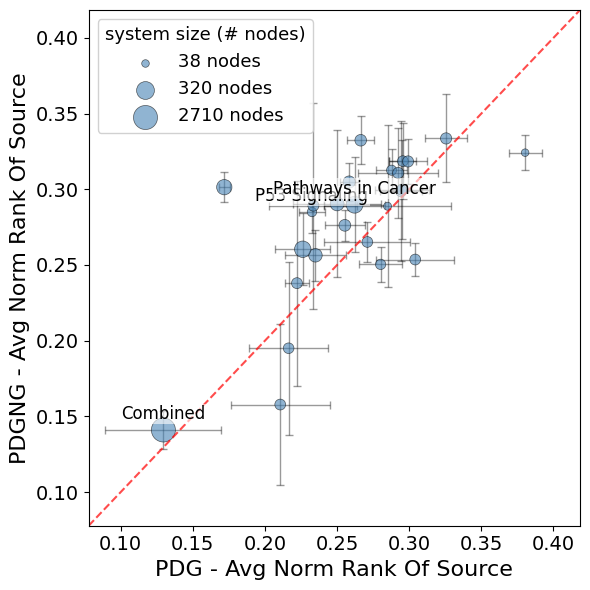

Saved plot to comparison_scatter_accuracy_mean.png


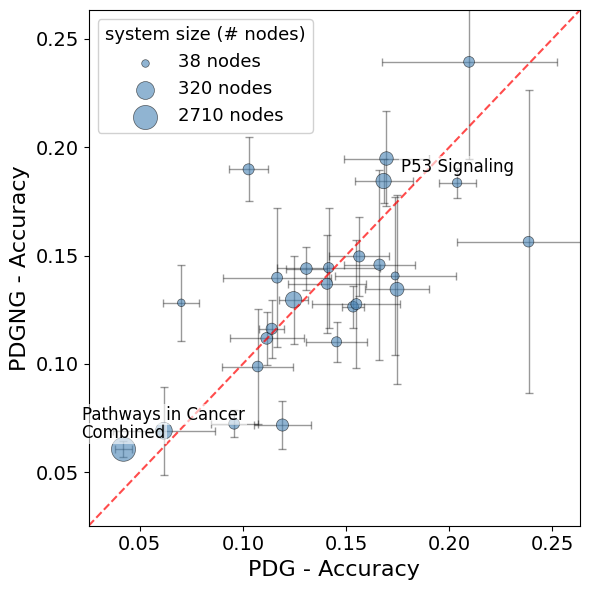

Saved plot to comparison_scatter_source_in_top_20_mean.png


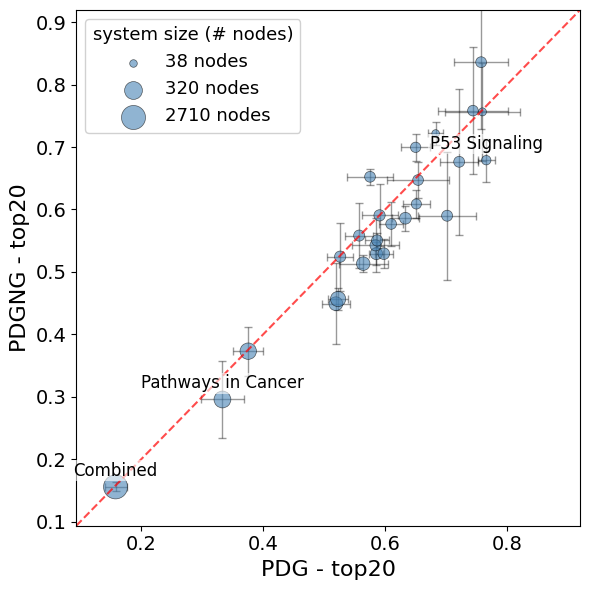

In [24]:
# =========================
# Plot grid: rows = metadata metrics, columns = metrics
# =========================

# Collect all number_of_nodes values for consistent size scaling
all_node_counts = []
for perf_metric in metrics:
    for exp in data[perf_metric]["experiment"]:
        node_count = kegg_all_metrics.get(normalize_name(exp), {}).get("number_of_nodes", np.nan)
        if not np.isnan(node_count):
            all_node_counts.append(node_count)

all_node_counts = np.array(all_node_counts, dtype=float)
min_nodes = np.min(all_node_counts)
max_nodes = np.max(all_node_counts)

# Size scaling: log scale for nodes, mapped to reasonable point sizes
size_min, size_max = 30, 300
log_min_nodes = np.log10(min_nodes)
log_max_nodes = np.log10(max_nodes)

def node_count_to_size(n):
    """Convert node count to point size using log scale"""
    if np.isnan(n) or n <= 0:
        return 50
    log_n = np.log10(n)
    normalized = (log_n - log_min_nodes) / (log_max_nodes - log_min_nodes)
    return size_min + normalized * (size_max - size_min)

# =========================
# Create separate plots for each metric
# =========================

for perf_metric in metrics:
    fig, ax = plt.subplots(1, 1, figsize=(fig_xsize, fig_ysize))

    x = np.array(data[perf_metric]["pdgrapher"], dtype=float)
    y = np.array(data[perf_metric]["pdgraphernognn"], dtype=float)
    xerr = data[perf_metric]["pdgrapher_std"]
    yerr = data[perf_metric]["pdgraphernognn_std"]
    exps = data[perf_metric]["experiment"]

    # Get node counts for sizing
    node_counts = []
    sizes = []
    for exp in exps:
        node_count = kegg_all_metrics.get(normalize_name(exp), {}).get("number_of_nodes", np.nan)
        node_counts.append(node_count)
        sizes.append(node_count_to_size(node_count))

    # Neutral color with size based on number of nodes
    scatter = ax.scatter(
        x,
        y,
        c="steelblue",
        s=sizes,
        alpha=0.6,
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=1,
        alpha=0.4,
        capsize=3,
        zorder=1,
    )

    # Annotate outliers (top/bottom 10% in either x or y direction)
    combined_vals = np.concatenate([x, y])
    threshold_high = np.percentile(combined_vals, 99)
    threshold_low = np.percentile(combined_vals, 1)

    exp_label_dict = {
        "combined": "Combined",
        #"olfactory_transduction": "Olfactory Transduction",
        #"colorectal_cancer": "Colorectal Cancer",
        #"circadian_entrainment": "Circadian Entrainment",
        "pathway": "Pathways in Cancer",
        #"neurodegeneration_multiples": "Neurodegeneration Multiples",
        #"vascular_smooth_muscle_contraction": "Vascular Smooth Muscle Contraction",
        "p53_signaling": "P53 Signaling",
    }

    
    for j, experiment in enumerate(exps):
        is_outlier = x[j] >= threshold_high or x[j] <= threshold_low or \
                    y[j] >= threshold_high or y[j] <= threshold_low
        
        if experiment.lower() in exp_label_dict:
            ax.annotate(
                exp_label_dict.get(experiment.lower(), experiment),
                (x[j], y[j]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=point_label_fontsize,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1),
            )

    # if len(x) > 1:
    #     corr, _ = pearsonr(x, y)
    #     ax.set_title(f"{perf_metric}\nPearson r = {corr:.2f}")
    # else:
    #     ax.set_title(perf_metric)

    metric_name = perf_metric.replace("_mean", "").replace("_", " ").title()
    metric_label_dict = {
        "avg norm rank of source_mean": "norm avg rank",
        "accuracy": "accuracy",
        "Source In Top 20": "top20",
    }

    ax.set_xlabel("PDG - " + metric_label_dict.get(metric_name, metric_name), fontsize=axis_label_size)
    ax.set_ylabel("PDGNG - " + metric_label_dict.get(metric_name, metric_name), fontsize=axis_label_size)

    # Use same min/max for both axes
    all_vals = np.concatenate([x, y])
    axis_min = np.min(all_vals) * 0.6
    axis_max = np.max(all_vals) * 1.1
    ax.set_xlim(axis_min, axis_max)
    ax.set_ylim(axis_min, axis_max)
    
    ax.plot([axis_min, axis_max], [axis_min, axis_max], "r--", alpha=0.7)

    # Add size legend
    legend_sizes = [min_nodes, (min_nodes * max_nodes) ** 0.5, max_nodes]
    legend_labels = [f"{int(s)} nodes" for s in legend_sizes]
    legend_handles = [plt.scatter([], [], s=node_count_to_size(s), c="steelblue", 
                                 alpha=0.6, edgecolors="black", linewidths=0.5) 
                     for s in legend_sizes]
    
    ax.legend(handles=legend_handles, labels=legend_labels, title="system size (# nodes)",
              loc='upper left', framealpha=0.9, fontsize=legend_fontsize, title_fontsize=legend_title_fontsize)

    # Add filter info to title
    filter_info = ""
    if metadata_ranges:
        filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
        filter_info = f" (Filtered: {', '.join(filter_parts)})"
    
    if filter_info:
        fig.suptitle(f"{perf_metric}{filter_info}", fontsize=12, y=0.98)
    
   # plt.title("A", fontsize=16)
    # set size of figure

    # set tick label size
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

    plt.tight_layout()

    # Save figure
    output_filename = f"comparison_scatter_{perf_metric.replace(' ', '_')}.png"
    plt.savefig(output_filename)
    print(f"Saved plot to {output_filename}")
    plt.show()
    plt.close(fig)


Saved plot to comparison_ratio_avg_norm_rank_of_source_mean.png


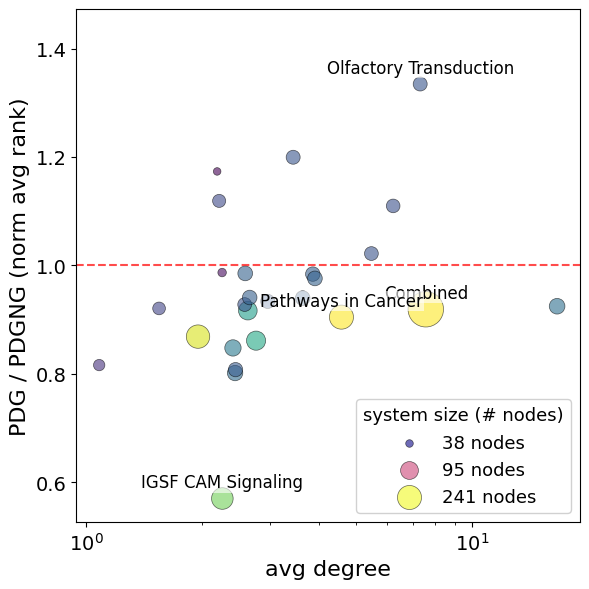

Saved plot to comparison_ratio_accuracy_mean.png


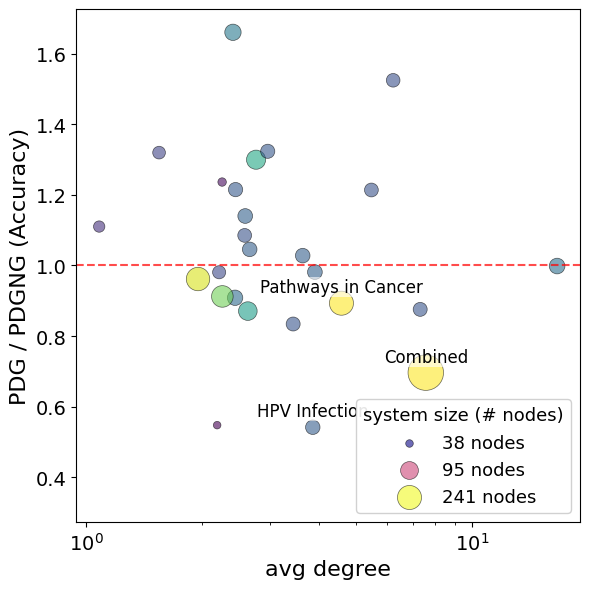

Saved plot to comparison_ratio_source_in_top_20_mean.png


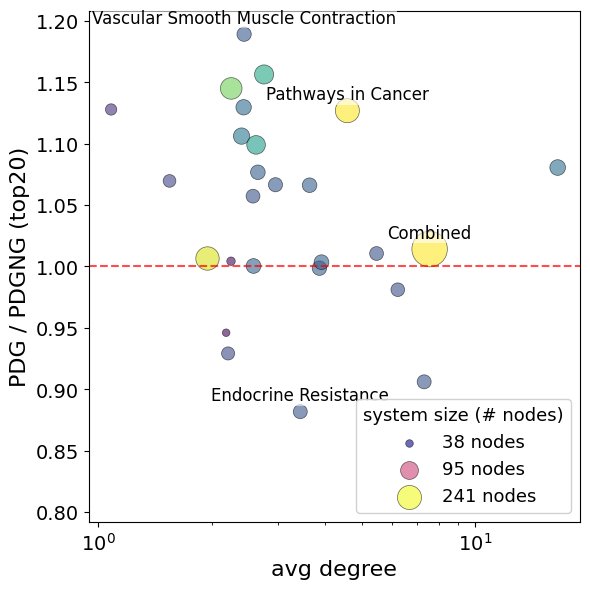

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LogNorm

# Use only one metadata metric: number_of_sig_info_in_pathway
meta_metric = "average_degree"  # Change this to the desired metadata metric for x-axis

# ============================================================
# Collect all node counts for consistent size scaling
# ============================================================
all_node_counts = []
for perf_metric in metrics:
    for exp in data[perf_metric]["experiment"]:
        if "combined" in exp.lower():
            continue
        node_count = kegg_all_metrics.get(normalize_name(exp), {}).get("number_of_nodes", np.nan)
        if not np.isnan(node_count):
            all_node_counts.append(node_count)

all_node_counts = np.array(all_node_counts, dtype=float)
min_nodes = np.min(all_node_counts)
max_nodes = np.max(all_node_counts)

# Size scaling: log scale for nodes, mapped to reasonable point sizes
size_min, size_max = 30, 300
log_min_nodes = np.log10(min_nodes)
log_max_nodes = np.log10(max_nodes)

def node_count_to_size(n):
    """Convert node count to point size using log scale"""
    if np.isnan(n) or n <= 0:
        return 50
    log_n = np.log10(n)
    normalized = (log_n - log_min_nodes) / (log_max_nodes - log_min_nodes)
    return size_min + normalized * (size_max - size_min)

exp_label_dict = {
    "combined": "Combined",
    "olfactory_transduction": "Olfactory Transduction",
    "colorectal_cancer": "Colorectal Cancer",
    #"circadian_entrainment": "Circadian Entrainment",
    "pathway": "Pathways in Cancer",
    #"neurodegeneration_multiples": "Neurodegeneration Multiples",
    "vascular_smooth_muscle_contraction": "Vascular Smooth Muscle Contraction",
    "p53_signaling": "P53 Signaling",
    #"egfr": "EGFR Signaling",
    "endocrine_resistance": "Endocrine Resistance",
    "igsf_cam_signaling": "IGSF CAM Signaling",
    #"breast_cancer": "Breast Cancer",
    "human_papillomavirus_infection": "HPV Infection",
}

# ============================================================
# Use node count ALSO for color (same as size)
# ============================================================
color_vmin, color_vmax = min_nodes, max_nodes

# Log normalization (consistent with size scaling)
color_norm = LogNorm(vmin=color_vmin, vmax=color_vmax)
color_label = "system size (#nodes, log scale)"

# ============================================================
# Create separate plots for each performance metric
# ============================================================

for perf_metric in metrics:
    fig, ax = plt.subplots(1, 1, figsize=(fig_xsize, fig_ysize))

    exps = data[perf_metric]["experiment"]
    pdgrapher_vals = np.array(data[perf_metric]["pdgrapher"], dtype=float)
    pdgraphernognn_vals = np.array(data[perf_metric]["pdgraphernognn"], dtype=float)
    pdgrapher_stds = np.array(data[perf_metric]["pdgrapher_std"], dtype=float)
    pdgraphernognn_stds = np.array(data[perf_metric]["pdgraphernognn_std"], dtype=float)

    # --- Filter and compute metadata, color, size, and ratio values ---
    meta_vals, color_vals, sizes, ratio_vals_filtered, exps_filtered = [], [], [], [], []
    upper_whiskers, lower_whiskers = [], []

    for exp_idx, exp in enumerate(exps):
        # if "combined" in exp.lower():
        #     continue

        exp_name = normalize_name(exp)
        exp_metrics = kegg_all_metrics.get(exp_name, {})

        # Metadata value for x-axis
        meta_val = exp_metrics.get(meta_metric, np.nan)
        meta_vals.append(meta_val)

        # Compute color: number_of_nodes (same as size)
        node_count = exp_metrics.get("number_of_nodes", np.nan)
        color_vals.append(node_count)

        # Compute size: number_of_nodes (log scale)
        node_count = exp_metrics.get("number_of_nodes", np.nan)
        sizes.append(node_count_to_size(node_count))

        # Compute ratio and whiskers
        pdg_mean = pdgrapher_vals[exp_idx]
        pdg_std = pdgrapher_stds[exp_idx]
        pdgng_mean = pdgraphernognn_vals[exp_idx]
        pdgng_std = pdgraphernognn_stds[exp_idx]
        
        ratio = pdg_mean / pdgng_mean
        ratio_vals_filtered.append(ratio)
        
        # Upper whisker: max pdgrapher / min pdgraphernognn
        max_pdg = pdg_mean + pdg_std
        min_pdgng = max(pdgng_mean - pdgng_std, 1e-10)  # avoid division by zero
        upper_bound = max_pdg / min_pdgng
        
        # Lower whisker: min pdgrapher / max pdgraphernognn  
        min_pdg = max(pdg_mean - pdg_std, 0)
        max_pdgng = pdgng_mean + pdgng_std
        lower_bound = min_pdg / max_pdgng if max_pdgng > 0 else 0
        
        upper_whiskers.append(upper_bound - ratio)
        lower_whiskers.append(ratio - lower_bound)
        
        exps_filtered.append(exp)

    meta_vals = np.array(meta_vals, dtype=float)
    color_vals = np.array(color_vals, dtype=float)
    ratio_vals_filtered = np.array(ratio_vals_filtered, dtype=float)
    upper_whiskers = np.array(upper_whiskers, dtype=float)
    lower_whiskers = np.array(lower_whiskers, dtype=float)

    # --- Scatter plot ---
    scatter = ax.scatter(
        meta_vals,
        ratio_vals_filtered,
        c=color_vals,
        cmap="viridis",
        norm=color_norm,
        s=sizes,
        alpha=0.6,
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )

    # # --- Add whiskers ---
    # ax.errorbar(
    #     meta_vals,
    #     ratio_vals_filtered,
    #     yerr=[lower_whiskers, upper_whiskers],
    #     fmt="none",
    #     ecolor="black",
    #     elinewidth=1,
    #     alpha=0.4,
    #     capsize=2,
    #     zorder=1,
    # )

    # --- Logarithmic x-axis ---
    ax.set_xscale("log")

    # --- Center y-axis around 1 ---
    ratio_min = np.nanmin(ratio_vals_filtered)
    ratio_max = np.nanmax(ratio_vals_filtered)
    max_distance = max(abs(ratio_max - 1.0), abs(ratio_min - 1.0))
    ax.set_ylim(1.0 - max_distance * 1.1, 1.0 + max_distance * 1.1)

    # --- Annotate outliers (top/bottom 15% in y-direction) ---
    ratio_threshold_high = np.percentile(ratio_vals_filtered, 97)
    ratio_threshold_low = np.percentile(ratio_vals_filtered, 3)
    
    for j, ratio in enumerate(ratio_vals_filtered):
        is_outlier = ratio >= ratio_threshold_high or ratio <= ratio_threshold_low
        if "combined" in exps_filtered[j].lower():
            is_outlier = True  # Always label the combined point
        if "pathway" in exps_filtered[j].lower():
            is_outlier = True  # Always label the pathway point
        
        if is_outlier and exps_filtered[j].lower() in exp_label_dict:
            ax.annotate(
                exp_label_dict.get(exps_filtered[j].lower(), exps_filtered[j]),
                (meta_vals[j], ratio_vals_filtered[j]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=point_label_fontsize,
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none", pad=1),
            )

    # --- Labels and reference line ---
    metric_label_dict = {
        "Avg Norm Rank Of Source": "norm avg rank",
        "accuracy": "accuracy",
        "Source In Top 20": "top20",
        "Number Of Sig Info In Pathway": "#L1000 data",
        "Average Degree": "avg degree",
    }
    ax.set_xlabel(metric_label_dict.get(meta_metric.replace("_", " ").title(), meta_metric.replace("_", " ").title()), fontsize=axis_label_size)
    metric_label = perf_metric
    if metric_label.lower().endswith("_mean"):
        metric_label = metric_label[:-5]
    metric_label = metric_label.replace('_', ' ').title()
    ax.set_ylabel(f"PDG / PDGNG ({metric_label_dict.get(metric_label, metric_label)})", fontsize=axis_label_size)
    #ax.set_title(perf_metric)
    ax.axhline(1.0, color="r", linestyle="--", alpha=0.7)

    #set ticklabel size
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

    from matplotlib.cm import ScalarMappable

# --- Size + color legend (combined) ---
    legend_sizes = [min_nodes, (min_nodes * max_nodes) ** 0.5, max_nodes]
    legend_labels = [f"{int(s)} nodes" for s in legend_sizes]

    # Create a ScalarMappable for mapping node count → color
    sm = ScalarMappable(cmap="plasma", norm=color_norm)
    sm.set_array([])  # required but dummy

    legend_handles = [
        plt.scatter(
            [], [],
            s=node_count_to_size(s),
            color=sm.to_rgba(s),   # map node count to color
            alpha=0.6,
            edgecolors="black",
            linewidths=0.5
        ) for s in legend_sizes
    ]

    ax.legend(
        handles=legend_handles,
        labels=legend_labels,
        title="system size (# nodes)",
        loc='lower right',
        framealpha=0.9,
        fontsize=legend_fontsize,
        title_fontsize=legend_title_fontsize
    )

    # # --- Colorbar ---
    # cbar = plt.colorbar(scatter, ax=ax)
    # cbar.set_label(color_label)

    # # --- Size legend ---
    # legend_sizes = [min_nodes, (min_nodes * max_nodes) ** 0.5, max_nodes]
    # legend_labels = [f"{int(s)} nodes" for s in legend_sizes]
    # legend_handles = [plt.scatter([], [], s=node_count_to_size(s), c="gray", 
    #                              alpha=0.6, edgecolors="black", linewidths=0.5) 
    #                  for s in legend_sizes]
    
    # ax.legend(handles=legend_handles, labels=legend_labels, title="system size (# nodes)",
    #           loc='lower left', framealpha=0.9, fontsize=12, title_fontsize=14)

    # --- Figure title and layout ---
    filter_info = ""
    if metadata_ranges:
        filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
        filter_info = f" (Filtered: {', '.join(filter_parts)})"
    
    if filter_info:
        fig.suptitle(f"{perf_metric}{filter_info}", fontsize=12, y=0.98)

    # set size of figure
    #fig.set_size_inches(7, 6)

    plt.tight_layout()
    plt.tight_layout()
    # --- Save figure ---
    output_filename = f"comparison_ratio_{perf_metric.replace(' ', '_')}.png"
    plt.savefig(output_filename)
    print(f"Saved plot to {output_filename}")
    plt.show()
    plt.close(fig)

Saved plot to comparison_training_data_vs_degree_avg_norm_rank_of_source_mean.png
  Ratio range for avg norm rank of source_mean: [0.570, 1.430]


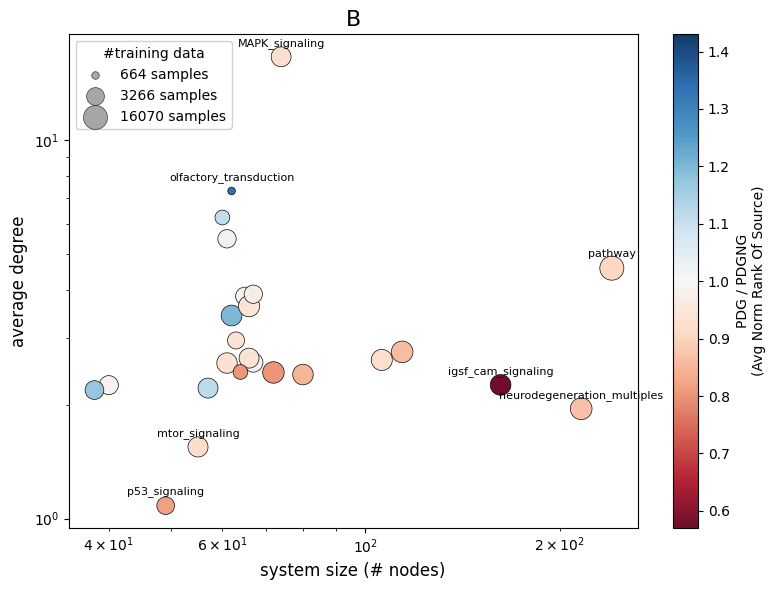

Saved plot to comparison_training_data_vs_degree_accuracy_mean.png
  Ratio range for accuracy_mean: [0.340, 1.660]


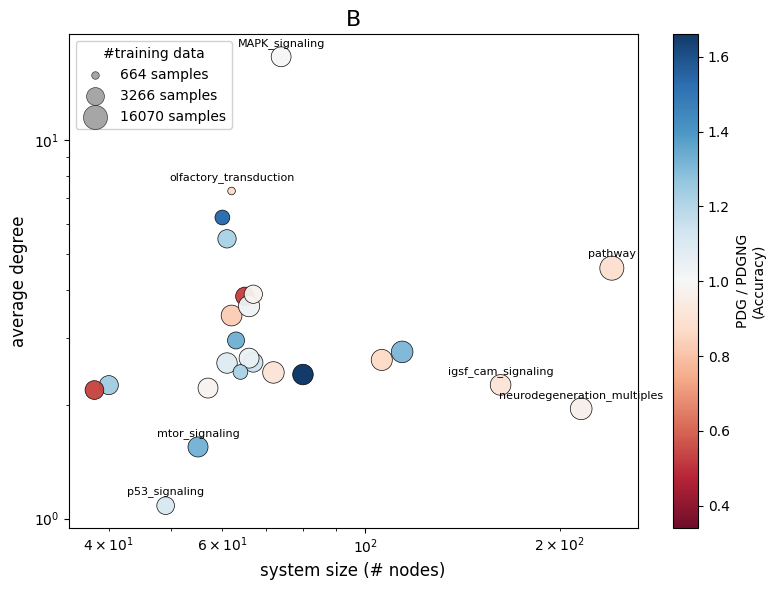

Saved plot to comparison_training_data_vs_degree_source_in_top_20_mean.png
  Ratio range for source in top 20_mean: [0.811, 1.189]


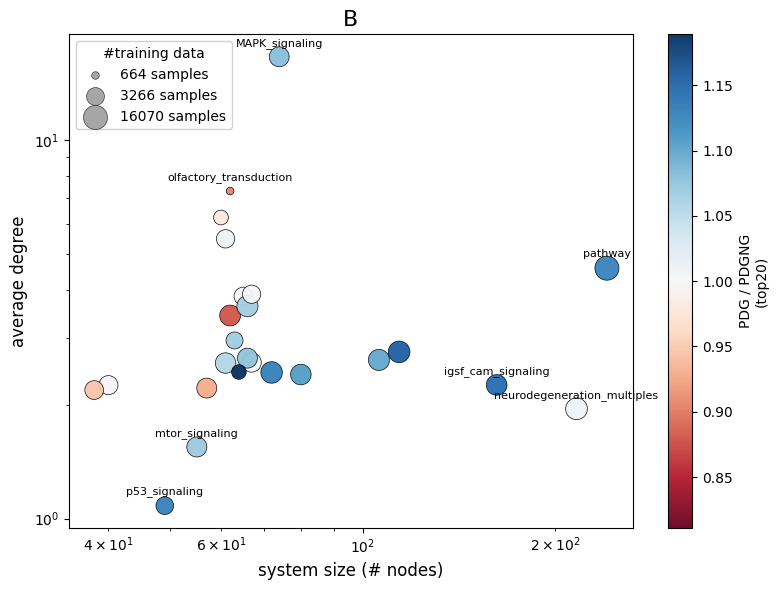

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# ============================================================
# Collect all training data amounts for consistent size scaling
# ============================================================
all_training_data = []
for perf_metric in metrics:
    for exp in data[perf_metric]["experiment"]:
        if "combined" in exp.lower():
            continue
        training_data = kegg_all_metrics.get(normalize_name(exp), {}).get("number_of_sig_info_in_pathway", np.nan)
        if not np.isnan(training_data):
            all_training_data.append(training_data)

all_training_data = np.array(all_training_data, dtype=float)
min_training = np.min(all_training_data)
max_training = np.max(all_training_data)

# Size scaling: log scale for training data, mapped to reasonable point sizes
size_min, size_max = 30, 300
log_min_training = np.log10(min_training)
log_max_training = np.log10(max_training)

def training_data_to_size(n):
    """Convert training data amount to point size using log scale"""
    if np.isnan(n) or n <= 0:
        return 50
    log_n = np.log10(n)
    normalized = (log_n - log_min_training) / (log_max_training - log_min_training)
    return size_min + normalized * (size_max - size_min)

# ============================================================
# Create separate plots for each performance metric
# ============================================================

for perf_metric in metrics:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))

    exps = data[perf_metric]["experiment"]
    pdgrapher_vals = np.array(data[perf_metric]["pdgrapher"], dtype=float)
    pdgraphernognn_vals = np.array(data[perf_metric]["pdgraphernognn"], dtype=float)

    # --- Collect x, y, color, and size values ---
    x_vals, y_vals, color_vals, sizes, exps_filtered = [], [], [], [], []

    for exp_idx, exp in enumerate(exps):
        if "combined" in exp.lower():
            continue

        exp_name = normalize_name(exp)
        exp_metrics = kegg_all_metrics.get(exp_name, {})

        # X-axis: number_of_nodes
        num_nodes = exp_metrics.get("number_of_nodes", np.nan)
        x_vals.append(num_nodes)

        # Y-axis: average_degree
        avg_degree = exp_metrics.get("average_degree", np.nan)
        y_vals.append(avg_degree)

        # Color: ratio pdgrapher / pdgraphernognn
        pdg_mean = pdgrapher_vals[exp_idx]
        pdgng_mean = pdgraphernognn_vals[exp_idx]
        ratio = pdg_mean / pdgng_mean
        color_vals.append(ratio)

        # Size: number_of_sig_info_in_pathway (log scale)
        training_data = exp_metrics.get("number_of_sig_info_in_pathway", np.nan)
        sizes.append(training_data_to_size(training_data))
        
        exps_filtered.append(exp)

    x_vals = np.array(x_vals, dtype=float)
    y_vals = np.array(y_vals, dtype=float)
    color_vals = np.array(color_vals, dtype=float)

    # ============================================================
    # Color normalization per metric (SYMMETRICAL around 1.0)
    # ============================================================
    # Calculate maximum distance from 1.0 to ensure symmetry for THIS metric
    max_distance = max(abs(np.nanmax(color_vals) - 1.0), abs(np.nanmin(color_vals) - 1.0))
    ratio_vmin = 1.0 - max_distance
    ratio_vmax = 1.0 + max_distance

    # Create diverging colormap centered at 1.0 with symmetrical bounds
    # Red for <1, white for =1, blue for >1
    color_norm = TwoSlopeNorm(vmin=ratio_vmin, vcenter=1.0, vmax=ratio_vmax)

    # --- Scatter plot ---
    scatter = ax.scatter(
        x_vals,
        y_vals,
        c=color_vals,
        cmap="RdBu",  # Red for <1, white for =1, blue for >1
        norm=color_norm,
        s=sizes,
        alpha=0.95,  # High alpha for saturated colors
        edgecolors="black",
        linewidths=0.5,
        zorder=2,
    )

    # --- Logarithmic x-axis ---
    ax.set_xscale("log")
    
    # --- Logarithmic y-axis ---
    ax.set_yscale("log")

    # --- Annotate isolated points (highest distance to nearest neighbor) ---
    # Work in log space since axes are logarithmic
    log_x = np.log10(x_vals)
    log_y = np.log10(y_vals)
    
    # Calculate nearest neighbor distance for each point
    nearest_distances = []
    for i in range(len(log_x)):
        distances = []
        for j in range(len(log_x)):
            if i != j:
                # Euclidean distance in log space
                dist = np.sqrt((log_x[i] - log_x[j])**2 + (log_y[i] - log_y[j])**2)
                distances.append(dist)
        nearest_distances.append(np.min(distances) if distances else 0)
    
    nearest_distances = np.array(nearest_distances)
    
    # Label top 15% most isolated points
    distance_threshold = np.percentile(nearest_distances, 75)
    
    for j, dist in enumerate(nearest_distances):
        if dist >= distance_threshold:
            ax.annotate(
                exps_filtered[j],
                (x_vals[j], y_vals[j]),
                textcoords="offset points",
                xytext=(0, 8),
                ha="center",
                fontsize=8,
            )

    # --- Labels ---
    ax.set_xlabel("system size (# nodes)", fontsize=12)
    ax.set_ylabel("average degree", fontsize=12)
    
    metric_label = perf_metric
    if metric_label.lower().endswith("_mean"):
        metric_label = metric_label[:-5]

    # --- Colorbar ---
    metric_label = metric_label.replace('_', ' ').title()
    metric_label_dict = {
        "avg norm rank of source_mean": "norm avg rank",
        "accuracy": "accuracy",
        "Source In Top 20": "top20",
    }
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(f"PDG / PDGNG\n({metric_label_dict.get(metric_label, metric_label)})", fontsize=10)

    # --- Size legend ---
    legend_sizes = [min_training, (min_training * max_training) ** 0.5, max_training]
    legend_labels = [f"{int(s)} samples" for s in legend_sizes]
    legend_handles = [plt.scatter([], [], s=training_data_to_size(s), c="gray", 
                                 alpha=0.7, edgecolors="black", linewidths=0.5) 
                     for s in legend_sizes]
    
    ax.legend(handles=legend_handles, labels=legend_labels, title="#training data",
              loc='upper left', framealpha=0.9)

    # --- Figure title ---
    filter_info = ""
    if metadata_ranges:
        filter_parts = [f"{k}: [{v[0]}, {v[1]}]" for k, v in metadata_ranges.items()]
        filter_info = f" (Filtered: {', '.join(filter_parts)})"
    
    if filter_info:
        fig.suptitle(f"{perf_metric}{filter_info}", fontsize=12, y=0.98)
    plt.title("B", fontsize=16)
    # set size of figure
    fig.set_size_inches(8, 6)

    plt.tight_layout()
    
    # --- Save figure ---
    output_filename = f"comparison_training_data_vs_degree_{perf_metric.replace(' ', '_')}.png"
    plt.savefig(output_filename, dpi=300)  # Higher DPI for better quality
    print(f"Saved plot to {output_filename}")
    print(f"  Ratio range for {perf_metric}: [{ratio_vmin:.3f}, {ratio_vmax:.3f}]")
    plt.show()
    plt.close(fig)